In [1]:
import scanpy as sc
import scvi 
import matplotlib.pyplot as plt

W0804 16:19:30.765000 1644 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [23]:
adata = sc.read_h5ad("C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Annotation_Comparison/Clint-Samuel_annotation.h5ad")

In [24]:
adata

AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', 'Clint_annotation', 'Clint_annotation_v2'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject_mea

In [25]:
adata.obs[adata.obs["orig.ident"] == "SAM3"][
    "Clint_annotation_v2"
].value_counts()

Clint_annotation_v2
Late Immature          4429
Early Immature         2800
Proliferating cDC1s    2118
Early Mature            813
Late Mature             572
Other cDC1s               0
Name: count, dtype: int64

Preprocessing

In [26]:
adata.raw = adata  # keep full dimension safe

print(f"Number of genes before HVG selection: {adata.n_vars}")
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=4000,
    layer=None,
    subset=True,
)

print(f"Number of genes after HVG selection: {adata.n_vars}")

Number of genes before HVG selection: 36048
Number of genes after HVG selection: 4000


In [27]:
# check all labels in SAM3, to make sure all cells are represented
labels_in_sample = adata[adata.obs["orig.ident"] == "SAM3"].obs["Clint_annotation_v2"].unique().tolist()
print("Labels present in sample:", labels_in_sample)

Labels present in sample: ['Late Immature', nan, 'Proliferating cDC1s', 'Early Mature', 'Late Mature', 'Early Immature']


In [28]:
# 1. Create a copy of your annotation column
adata.obs["scanvi_labels_before"] = adata.obs["Clint_annotation_v2"].astype(str)

# 2. Mask out all samples EXCEPT your one verified sample
verified_sample_id = "SAM3"  # replace with your target sample ID

# Set everything not in your verified sample to "Unknown"
is_not_verified = adata.obs["orig.ident"] != verified_sample_id
adata.obs.loc[is_not_verified, "scanvi_labels_before"] = "Unknown"

# Convert back to categorical (scvi-tools requirement)
adata.obs["scanvi_labels_before"] = adata.obs["scanvi_labels_before"].astype("category")

In [29]:
# 3. Setup AnnData for scANVI
scvi.model.SCANVI.setup_anndata(
    adata,
    batch_key="orig.ident",       # handles batch effects across samples
    labels_key="scanvi_labels_before",   # our column with sample 1 labeled, rest "Unknown"
    unlabeled_category="Unknown"  # tells scANVI which cells need annotation
)

Train model. It is better to first train an scVI model, and then train the scANVI model based on that, but we don't have the time for that. scANVI on its own should also perform well.

In [30]:
# 4. Initialize and Train scANVI
scanvi_model = scvi.model.SCANVI(adata)

# train model, with max epochs 
scanvi_model.train(max_epochs = 1000,
            early_stopping=True,
            accelerator = "cpu",
            plan_kwargs = {"lr": 1e-3},
            check_val_every_n_epoch = 10,
            enable_progress_bar = True
            )

INFO     Training for 1000 epochs.                                                                                 


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
c:\Users\irc\miniconda3\envs\tv\lib\site-packages\lightning\pytorch\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\irc\miniconda3\envs\tv\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\irc\miniconda3\envs\tv\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performan

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1232.492. Signaling Trainer to stop.


In [31]:
# save model
scanvi_model.save("scANVI_integration_model", overwrite=True)

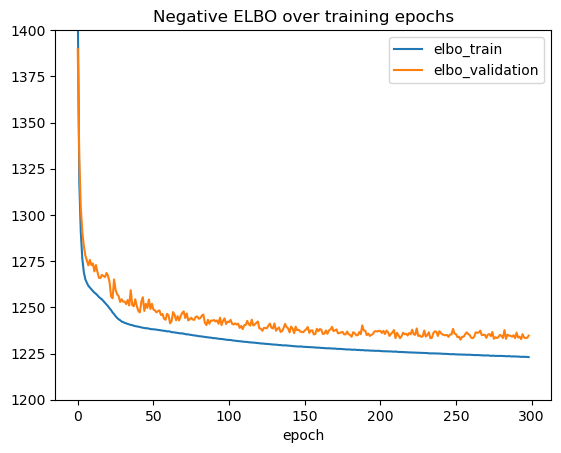

In [32]:
fig, ax = plt.subplots(1, 1)
scanvi_model.history["elbo_train"].plot(ax=ax, label="train")
scanvi_model.history["elbo_validation"].plot(ax=ax, label="validation")
ax.set(title="Negative ELBO over training epochs", ylim=(1200, 1400))
ax.legend()

Get annotation

In [33]:
# 5. Predict labels for the entire dataset
adata.obs["scanvi_predicted"] = scanvi_model.predict()

# Optional: Get prediction confidence scores (0.0 to 1.0)
adata.obs["scanvi_confidence"] = scanvi_model.predict(soft=True).max(axis=1)

In [34]:
# store the latent representation in the adata object
SCANVI_LATENT_KEY = "X_scANVI"
adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation()

Visualize

In [41]:
# calculate these metrics for the latent representation
# here, we use the latent coordinates, not PCA coordinates for the neighbourhood graph
sc.pp.neighbors(adata, use_rep=SCANVI_LATENT_KEY)
sc.tl.leiden(
    adata,
    resolution=1.0,
    key_added="leiden_1_scANVI",
    flavor="igraph",
    n_iterations=2,
    directed=False
)

sc.tl.umap(adata) # calculates UMAP coordinates, not needed actually if we use the latent space from scANVI

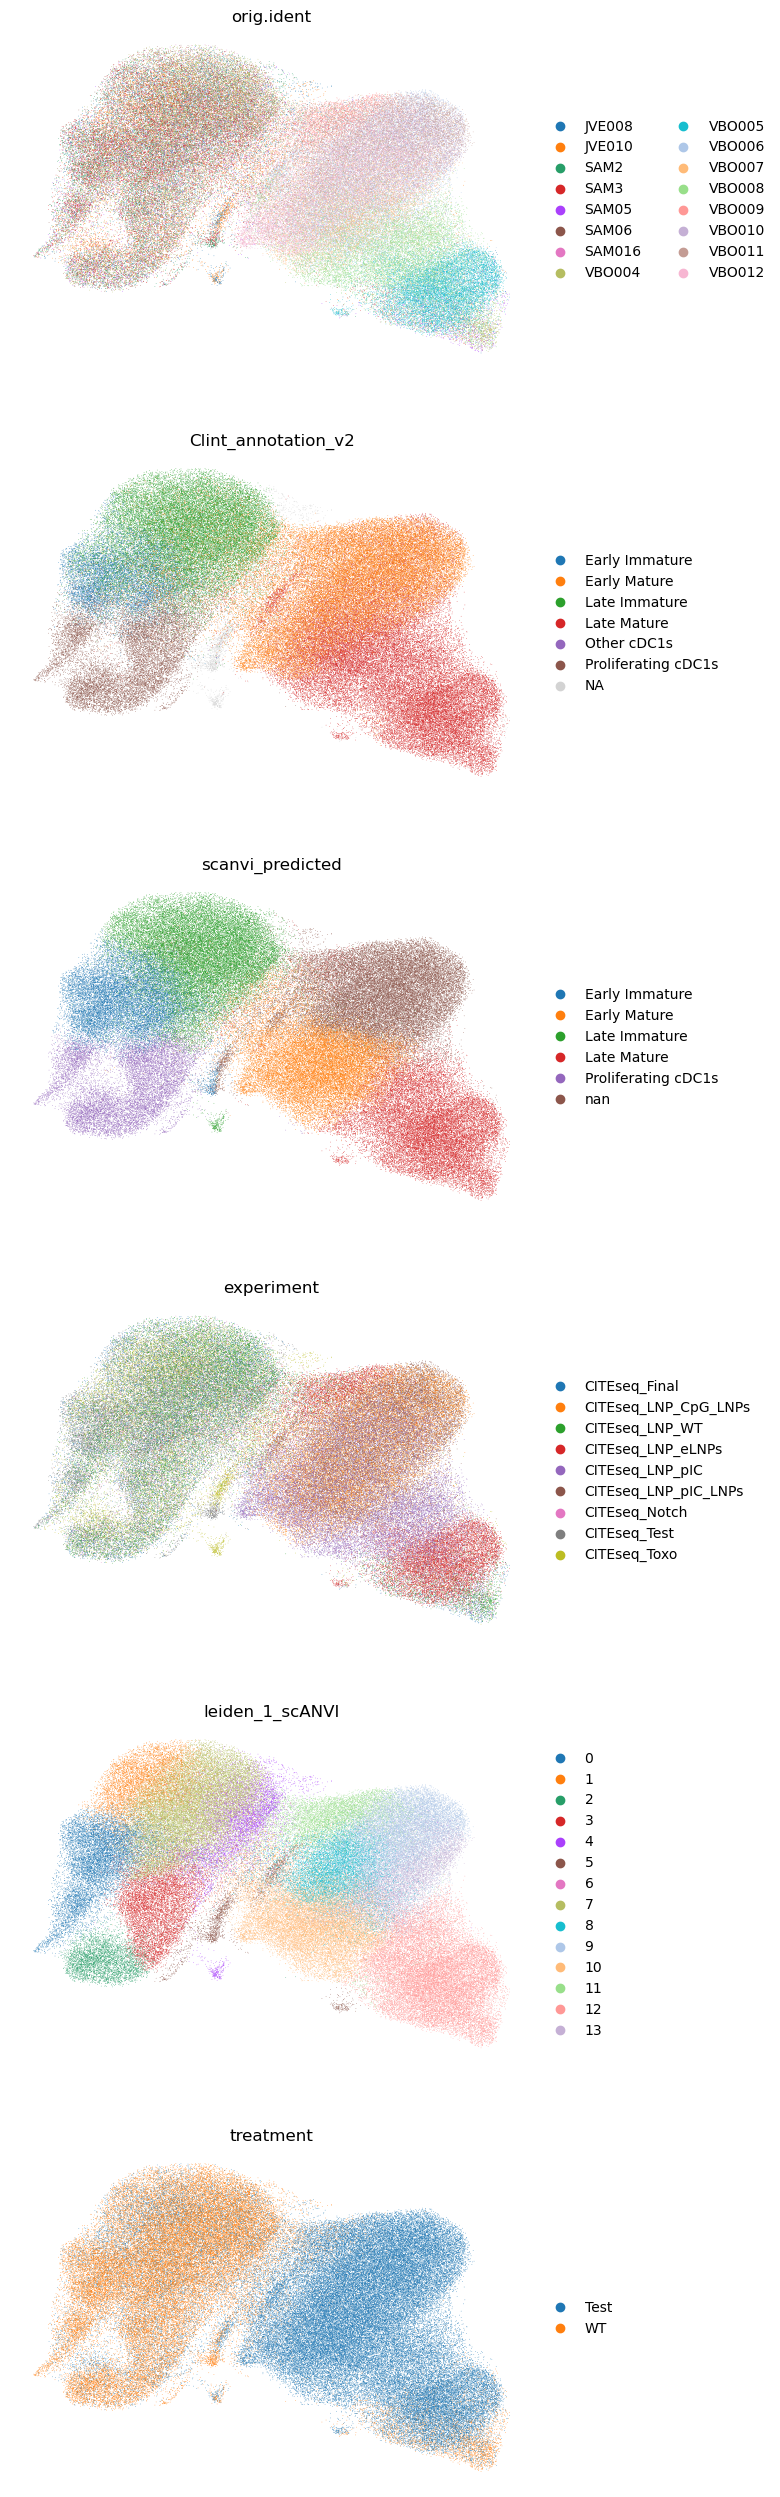

In [42]:
sc.pl.umap(adata,
           color=["orig.ident", "Clint_annotation_v2", "scanvi_predicted", "experiment", "leiden_1_scANVI", "treatment"],
           frameon=False,
           legend_loc="right margin",
           ncols=1)

In [46]:
adata.write("scANVI_annotation.h5ad")

In [43]:
adata

AnnData object with n_obs × n_vars = 137062 × 4000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', 'Clint_annotation', 'Clint_annotation_v2', 'scanvi_labels_before', '_scvi_batch', '_scvi_labels', 'scanvi_predicted', 'scanvi_confidence', 'leiden_1_scANVI'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.S